# Example 4: Propeller Performance Analysis

## Overview

This notebook demonstrates:
1. Creating a propeller model using open water test data
2. Analyzing thrust and torque coefficients (Kt, Kq)
3. Calculating open water efficiency
4. Understanding advance ratio and propeller operating points
5. Comparing with B-series standard propellers
6. Calculating power requirements from resistance

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ship_model_lib.propulsor import (
    PropulsorDataOpenWater, 
    PropulsorDataBseries, 
    OpenWaterPropellerCurvePoint,
    ReCorrection,
)

## Part 1: Open Water Propeller Performance

### Key Concepts

**Advance Ratio:** $J = \frac{V_a}{n \cdot D}$

**Thrust Coefficient:** $K_t = \frac{T}{\rho n^2 D^4}$

**Torque Coefficient:** $K_q = \frac{Q}{\rho n^2 D^5}$

**Open Water Efficiency:** $\eta_0 = \frac{J}{2\pi} \cdot \frac{K_t}{K_q}$

Where:
- $V_a$ = Advance speed (m/s)
- $n$ = Rotation rate (rev/s)
- $D$ = Propeller diameter (m)
- $T$ = Thrust (N)
- $Q$ = Torque (Nm)
- $\rho$ = Water density (kg/m³)

In [2]:
# Define open water test data (typical for a 4-blade propeller)
j_ref = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
kt_ref = np.array([0.45, 0.42, 0.38, 0.33, 0.28, 0.22, 0.15, 0.08, 0.00])
kq_ref = np.array([0.070, 0.065, 0.058, 0.050, 0.042, 0.033, 0.024, 0.015, 0.006])

open_water_curve_points = [
    OpenWaterPropellerCurvePoint(j=j, kt=kt, kq=kq)
    for j, kt, kq in zip(j_ref, kt_ref, kq_ref)
]
diameter_propeller_m = 5.5

print(f"Propeller Specifications:")
print(f"  Diameter:           {diameter_propeller_m} m")
print(f"  Number of Blades:   4")
print(f"  Wake Fraction:      0.25")
print(f"  Thrust Deduction:   0.18")

Propeller Specifications:
  Diameter:           5.5 m
  Number of Blades:   4
  Wake Fraction:      0.25
  Thrust Deduction:   0.18


In [3]:
# Create propulsor model
propeller = PropulsorDataOpenWater(
    propeller_curve_points=open_water_curve_points,
    dp_diameter_propeller_m=diameter_propeller_m,
)

print("✓ Propeller model created successfully")

✓ Propeller model created successfully


### Operating Point Analysis

In [4]:
vessel_speed_kn = 15.0
vessel_speed_mps = vessel_speed_kn * 0.514444
rpm = 120.0
n_rps = rpm / 60.0
j_operating = vessel_speed_mps / (n_rps * diameter_propeller_m)
kt_operating = propeller.get_kt(j_operating)
kq_operating = propeller.get_kq(j_operating)
eta0_operating = propeller.get_efficiency_open_water(j_operating)

print(f"Operating Point Analysis (J = {j_operating}):")
print(f"  Advance Ratio (J):          {j_operating:.3f}")
print(f"  Thrust Coefficient (Kt):    {kt_operating:.4f}")
print(f"  Torque Coefficient (Kq):    {kq_operating:.5f}")
print(f"  Open Water Efficiency (η₀): {eta0_operating:.4f} ({eta0_operating*100:.2f}%)")

# Calculate hull and propulsive efficiency
propeller_operating_point = propeller.get_propulsor_data_from_vessel_speed_rps(
    vessel_speed_kn=vessel_speed_kn,
    n_rps=n_rps,
)
hull_efficiency = propeller_operating_point.efficiency_hull
print(f"\n  Hull Efficiency (ηH):       {hull_efficiency} ({hull_efficiency*100}%)")

# Typical values for other efficiency factors
relative_rotative_efficiency = 1.0
shaft_efficiency = 0.98

total_efficiency = eta0_operating * hull_efficiency * relative_rotative_efficiency * shaft_efficiency
print(f"  Total Propulsive Efficiency: {total_efficiency} ({total_efficiency*100}%)")

Operating Point Analysis (J = 0.7015145454545455):
  Advance Ratio (J):          0.702
  Thrust Coefficient (Kt):    0.1489
  Torque Coefficient (Kq):    0.02386
  Open Water Efficiency (η₀): 0.6968 (69.68%)

  Hull Efficiency (ηH):       [1.] ([100.]%)
  Total Propulsive Efficiency: [0.68290323] ([68.29032283]%)


### Performance Curves Analysis

In [5]:
# Generate smooth curves
j_smooth = np.linspace(0.1, 0.9, 100)
kt_smooth = np.array([propeller.get_kt(j) for j in j_smooth])
kq_smooth = np.array([propeller.get_kq(j) for j in j_smooth])
eta0_smooth = propeller.get_efficiency_open_water(j_smooth)

# Find optimal efficiency point
max_eta_idx = np.argmax(eta0_smooth)
j_optimal = j_smooth[max_eta_idx]
eta_optimal = eta0_smooth[max_eta_idx]

print(f"Optimal Operating Point:")
print(f"  Advance Ratio (J_opt):      {j_optimal:.3f}")
print(f"  Maximum Efficiency (η₀_max): {eta_optimal:.4f} ({eta_optimal*100:.2f}%)")

Optimal Operating Point:
  Advance Ratio (J_opt):      0.746
  Maximum Efficiency (η₀_max): 0.7075 (70.75%)


## Part 2: B-Series Propeller Comparison

The **Wageningen B-series** is a systematic series of propellers with varying geometry parameters.

In [6]:
# Create a B-series propeller with similar characteristics
number_blades = 4
blade_area_ratio = 0.55
pitch_diameter_ratio = 0.9

propeller_bseries = PropulsorDataBseries(
    pd_pitch_diameter_ratio=pitch_diameter_ratio,
    ear_blade_area_ratio=blade_area_ratio,
    dp_diameter_propeller_m=diameter_propeller_m,
    z_blade_number=number_blades,
    re_correction=ReCorrection.ITTC78
)

print(f"B-Series Propeller Specifications:")
print(f"  Diameter:              {diameter_propeller_m} m")
print(f"  Number of Blades:      {number_blades}")
print(f"  Pitch/Diameter Ratio:  {pitch_diameter_ratio}")
print(f"  Blade Area Ratio:      {blade_area_ratio}")

# Calculate B-series performance
kt_bseries = np.array([propeller_bseries.get_kt(j) for j in j_smooth])
kq_bseries = np.array([propeller_bseries.get_kq(j) for j in j_smooth])
eta0_bseries = propeller_bseries.get_efficiency_open_water(j_smooth)

# Compare at operating point
kt_bs_op = propeller_bseries.get_kt(j_operating)
eta0_bs_op = propeller_bseries.get_efficiency_open_water(j_operating)

print(f"\nB-Series at J = {j_operating}:")
print(f"  Kt:   {kt_bs_op:.4f}")
print(f"  η₀:   {eta0_bs_op:.4f} ({eta0_bs_op*100:.2f}%)")

B-Series Propeller Specifications:
  Diameter:              5.5 m
  Number of Blades:      4
  Pitch/Diameter Ratio:  0.9
  Blade Area Ratio:      0.55

B-Series at J = 0.7015145454545455:
  Kt:   0.1340
  η₀:   0.7502 (75.02%)


## Part 3: Comprehensive Visualization

→ Saved 'example_04_propeller_performance.png'


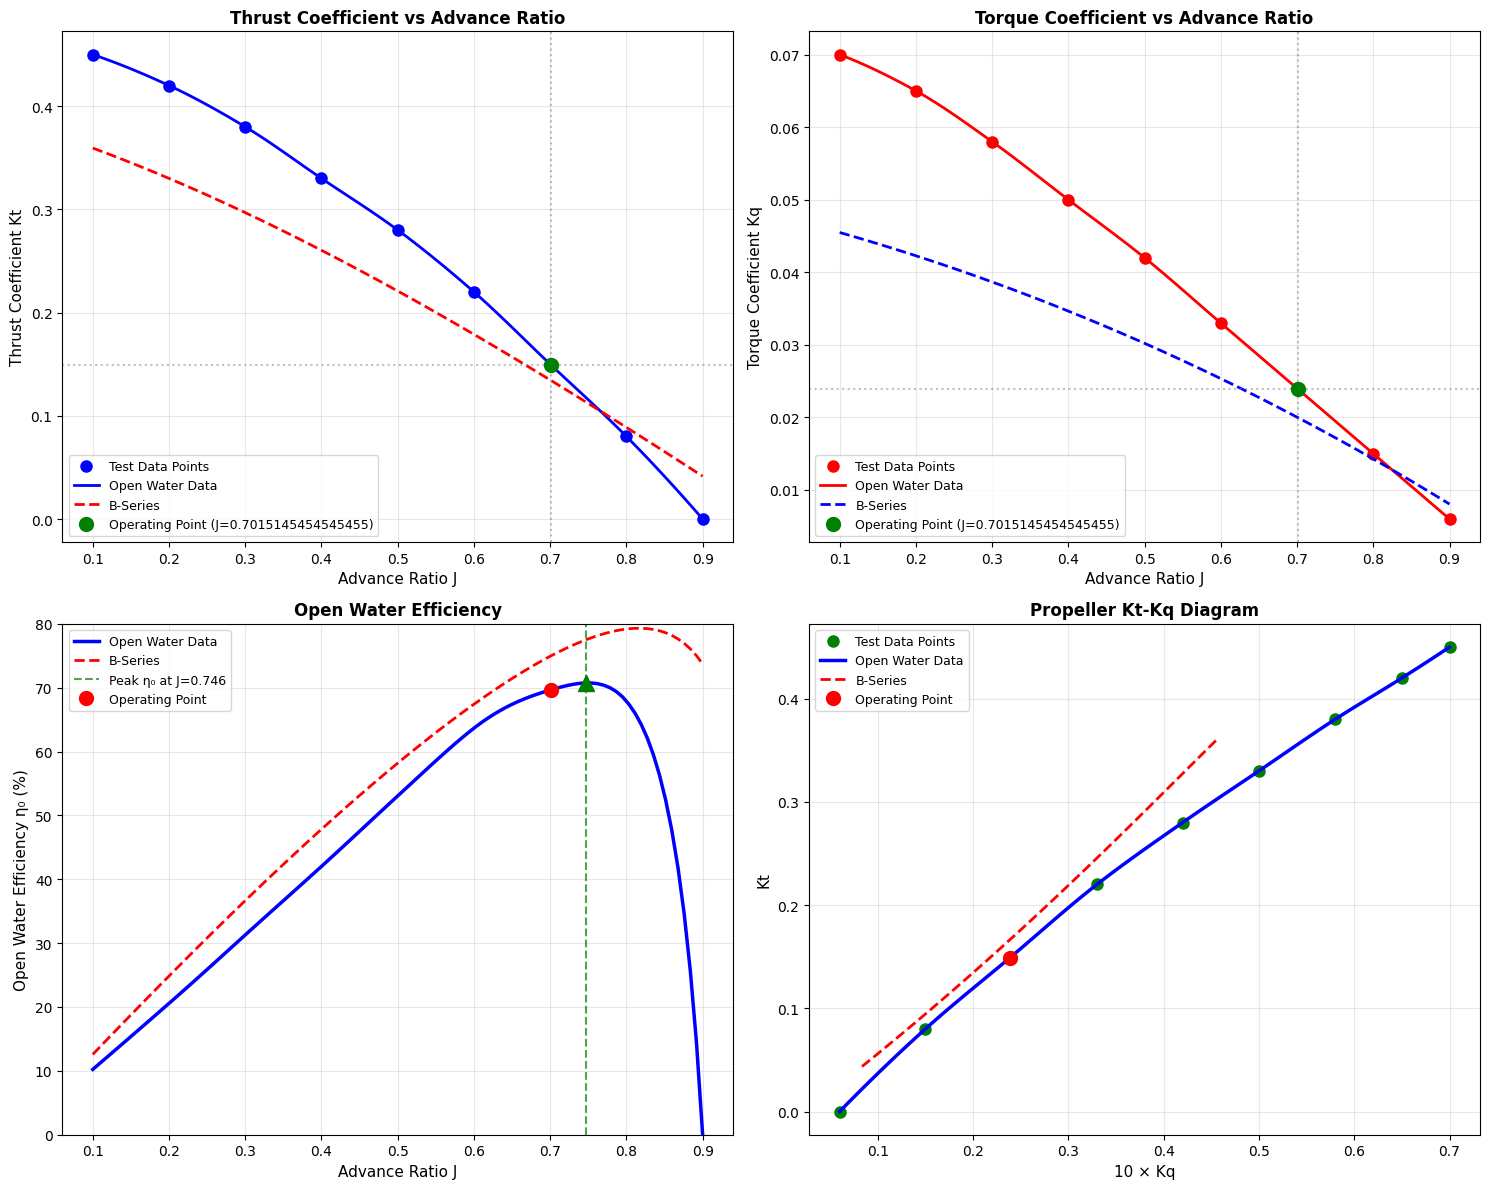

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Thrust Coefficient
ax1.plot(j_ref, kt_ref, 'bo', markersize=8, label='Test Data Points')
ax1.plot(j_smooth, kt_smooth, 'b-', linewidth=2, label='Open Water Data')
ax1.plot(j_smooth, kt_bseries, 'r--', linewidth=2, label='B-Series')
ax1.axvline(j_operating, color='gray', linestyle=':', alpha=0.5)
ax1.axhline(kt_operating, color='gray', linestyle=':', alpha=0.5)
ax1.plot(j_operating, kt_operating, 'go', markersize=10, label=f'Operating Point (J={j_operating})')
ax1.set_xlabel('Advance Ratio J', fontsize=11)
ax1.set_ylabel('Thrust Coefficient Kt', fontsize=11)
ax1.set_title('Thrust Coefficient vs Advance Ratio', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Plot 2: Torque Coefficient
ax2.plot(j_ref, kq_ref, 'ro', markersize=8, label='Test Data Points')
ax2.plot(j_smooth, kq_smooth, 'r-', linewidth=2, label='Open Water Data')
ax2.plot(j_smooth, kq_bseries, 'b--', linewidth=2, label='B-Series')
ax2.axvline(j_operating, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(kq_operating, color='gray', linestyle=':', alpha=0.5)
ax2.plot(j_operating, kq_operating, 'go', markersize=10, label=f'Operating Point (J={j_operating})')
ax2.set_xlabel('Advance Ratio J', fontsize=11)
ax2.set_ylabel('Torque Coefficient Kq', fontsize=11)
ax2.set_title('Torque Coefficient vs Advance Ratio', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# Plot 3: Open Water Efficiency
ax3.plot(j_smooth, eta0_smooth * 100, 'b-', linewidth=2.5, label='Open Water Data')
ax3.plot(j_smooth, eta0_bseries * 100, 'r--', linewidth=2, label='B-Series')
ax3.axvline(j_optimal, color='green', linestyle='--', alpha=0.7, label=f'Peak η₀ at J={j_optimal:.3f}')
ax3.plot(j_optimal, eta_optimal * 100, 'g^', markersize=12)
ax3.plot(j_operating, eta0_operating * 100, 'ro', markersize=10, label=f'Operating Point')
ax3.set_xlabel('Advance Ratio J', fontsize=11)
ax3.set_ylabel('Open Water Efficiency η₀ (%)', fontsize=11)
ax3.set_title('Open Water Efficiency', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)
ax3.set_ylim([0, 80])

# Plot 4: Kt vs 10*Kq (Classic propeller diagram)
ax4.plot(10 * kq_ref, kt_ref, 'go', markersize=8, label='Test Data Points')
ax4.plot(10 * kq_smooth, kt_smooth, 'b-', linewidth=2.5, label='Open Water Data')
ax4.plot(10 * kq_bseries, kt_bseries, 'r--', linewidth=2, label='B-Series')
ax4.plot(10 * kq_operating, kt_operating, 'ro', markersize=10, label=f'Operating Point')
ax4.set_xlabel('10 × Kq', fontsize=11)
ax4.set_ylabel('Kt', fontsize=11)
ax4.set_title('Propeller Kt-Kq Diagram', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('example_04_propeller_performance.png', dpi=150, bbox_inches='tight')
print("→ Saved 'example_04_propeller_performance.png'")
plt.show()

## Summary

In [8]:
print("Propeller Performance:")
print(f"  Optimal Efficiency:        {eta_optimal*100:.1f}% at J = {j_optimal:.3f}")
print(f"  Operating Efficiency:      {eta0_operating*100:.1f}% at J = {j_operating:.3f}")
print(f"  Total Propulsive Eff:      {total_efficiency[0]*100:.1f}%")

Propeller Performance:
  Optimal Efficiency:        70.7% at J = 0.746
  Operating Efficiency:      69.7% at J = 0.702
  Total Propulsive Eff:      68.3%


## Key Takeaways

1. **Open Water Performance:**
   - Kt decreases with increasing J
   - Efficiency peaks at moderate J values (typically 0.4-0.7)
   - Operating point should be near optimal efficiency

2. **B-Series vs Custom:**
   - B-series provides good baseline estimates
   - Custom propellers can be optimized for specific applications
   - Model test data is always preferred when available

3. **Power Requirements:**
   - Total propulsive efficiency typically 50-60%
   - Hull efficiency contribution significant
   - Engine power must account for all losses in power chain